# MapleFreight delivery delay prediction and Slack alerts
**AML 3303 — Assessment 1 · Student ID C0942109**

## 1. Context, problem and objective
MapleFreight wants dispatch to identify likely delays while shipments are in transit,
rather than learning about them from customer complaints. The decision is whether to
review a shipment for rerouting or advance customer notice.

This notebook builds and evaluates a binary classifier, selects an alert threshold,
and connects the predictions to a Slack Incoming Webhook. Predictions are made
**after pickup**, when pickup delay is known. The supplied CSV is historical;
the Slack demonstration is a clearly labelled replay.

In [1]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
import sys, json, hashlib, inspect, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
import joblib
from IPython.display import display, Markdown, Code, Image
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from dotenv import load_dotenv

ROOT = Path.cwd()
if not (ROOT / 'data/maplefreight_delivery_delay_dataset.csv').exists():
    raise FileNotFoundError('Start this notebook from the repository folder.')
sys.path.insert(0, str(ROOT))
from src.maplefreight import (clean_historical, DispatchFeatures, NUMERIC, ENGINEERED,
                             CATEGORICAL, PREDICTORS, TARGET, SEED)
from src.alerts import (score_shipments, build_alert, post_alert, alert_event_key)
for folder in ['reports', 'models', 'screenshots']:
    (ROOT / folder).mkdir(exist_ok=True)
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 4)
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
display(pd.DataFrame({
    'Decision': ['Prediction time', 'Positive outcome', 'Alert destination', 'Primary evaluation'],
    'Definition': ['After pickup, before delivery', 'delivered_late = 1',
                   '#all-lambton-college-software', 'Recall, precision, F1 and average precision']}))
display(Markdown('**Finding:** Delay prevention requires recall and a manageable review queue. '
    'Accuracy alone rewards predicting every shipment on time.'))

,Decision,Definition
0,Prediction time,"After pickup, before delivery"
1,Positive outcome,delivered_late = 1
2,Alert destination,#all-lambton-college-software
3,Primary evaluation,"Recall, precision, F1 and average precision"


**Finding:** Delay prevention requires recall and a manageable review queue. Accuracy alone rewards predicting every shipment on time.

## 2. Data understanding and quality audit
The raw source is preserved unchanged in `data/`. `actual_transit_hours` is available
only after delivery, so it is used solely for a label-quality audit and never as a
predictor. Shipment IDs identify records but are excluded from model features.

In [2]:
dataset_path = ROOT / 'data/maplefreight_delivery_delay_dataset.csv'
raw = pd.read_csv(dataset_path)
source_hash = hashlib.sha256(dataset_path.read_bytes()).hexdigest()
raw_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Unique shipment IDs', 'Exact duplicate rows',
               'Late shipments', 'Late share', 'Always-on-time accuracy'],
    'Value': [len(raw), raw.shape[1], raw.shipment_id.nunique(), raw.duplicated().sum(),
              raw[TARGET].sum(), raw[TARGET].mean(), 1 - raw[TARGET].mean()]})
display(raw_summary)
display(pd.DataFrame({'dtype': raw.dtypes.astype(str),
                      'missing': raw.isna().sum(),
                      'missing_pct': raw.isna().mean() * 100}))
display(raw.head(3))
display(raw.service_level.value_counts().rename('raw_count').to_frame())
display(Markdown(f'**Finding:** The export contains **{len(raw):,} rows** and '
    f'**{raw[TARGET].mean():.2%} late deliveries**. The majority baseline achieves '
    f'{1-raw[TARGET].mean():.2%} accuracy while detecting no late deliveries. '
    'Missing values and service-level case variants need treatment.'))

,Metric,Value
0,Rows,6035.0000
1,Columns,23.0000
2,Unique shipment IDs,6000.0000
3,Exact duplicate rows,32.0000
4,Late shipments,1242.0000
5,Late share,0.2058
6,Always-on-time accuracy,0.7942


,dtype,missing,missing_pct
shipment_id,object,0,0.0000
origin_city,object,0,0.0000
destination_city,object,0,0.0000
carrier,object,0,0.0000
service_level,object,0,0.0000
goods_type,object,0,0.0000
customer_priority_tier,object,0,0.0000
shipment_month,int64,0,0.0000
distance_km,float64,0,0.0000
weight_kg,float64,0,0.0000


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,2,0,7.53,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,0,0,1.00,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,0,0,7.12,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0


,raw_count
service_level,
Standard,3219
Express,1442
Economy,1254
standard,74
express,27
economy,19


**Finding:** The export contains **6,035 rows** and **20.58% late deliveries**. The majority baseline achieves 79.42% accuracy while detecting no late deliveries. Missing values and service-level case variants need treatment.

## 3. Data cleaning and feature availability
Trim categorical whitespace and canonicalize observed case variants. Remove
identical records after normalization **before any split**. Quarantine both rows
for the unresolved conflicting shipment ID rather than choosing an arbitrary copy.

The 40 weights above 50,000 kg are separated from the rest of the weight distribution
by a large gap. They may be unit errors, but the source unit cannot be verified.
Mask them and retain a suspect-weight indicator; fit median imputation on training
data only. Keep valid negative pickup delays, which mean early pickups.

In [3]:
display(Code(inspect.getsource(clean_historical), language='python'))
clean, quarantine, audit = clean_historical(raw)
quarantine.to_csv(ROOT / 'reports/quarantined_shipments.csv', index=False)
(ROOT / 'reports/data_audit.json').write_text(json.dumps(audit, indent=2))
display(pd.DataFrame({'Metric': audit.keys(), 'Value': [str(v) for v in audit.values()]}))
display(quarantine[['shipment_id', 'service_level', TARGET]])
feature_view = DispatchFeatures().transform(clean[PREDICTORS])
display(feature_view.isna().sum().loc[lambda s: s > 0].rename('missing_after_rules').to_frame())
on_time_exceeds_schedule = int(((clean[TARGET] == 0) &
    (clean.actual_transit_hours > clean.scheduled_transit_hours)).sum())
print('On-time labels with actual hours > scheduled hours:', on_time_exceeds_schedule)
print('Largest nonsuspect weight:', clean.loc[clean.weight_kg <= 50000, 'weight_kg'].max())
assert clean.shipment_id.is_unique
assert not set([TARGET, 'actual_transit_hours', 'shipment_id']).intersection(PREDICTORS)
display(Markdown(f'**Finding:** Cleaning leaves **{len(clean):,} unique shipments**, '
    f'with **{clean[TARGET].sum():,} late ({clean[TARGET].mean():.2%})**. '
    '34 normalized duplicate rows are removed and two conflicting rows quarantined. '
    f'{on_time_exceeds_schedule:,} on-time labels exceed scheduled hours: the promised-window '
    'definition needs clarification. Preserve the supplied target; do not reconstruct it from transit hours.'))

def clean_historical(raw):
    """Deduplicate before splitting; quarantine unresolved duplicate references."""
    frame = normalize_categories(raw)
    before = len(frame)
    frame = frame.drop_duplicates().copy()
    normalized_duplicates = before - len(frame)
    conflicting = frame['shipment_id'].duplicated(keep=False)
    quarantine = frame.loc[conflicting].copy()
    frame = frame.loc[~conflicting].reset_index(drop=True)
    if frame[TARGET].isna().any() or not frame[TARGET].isin([0, 1]).all():
        raise ValueError('Target must be present and binary; do not impute labels.')
    if not frame['shipment_id'].is_unique:
        raise ValueError('Shipment IDs must be unique before splitting.')
    audit = {'raw_rows': before, 'exact_duplicates': int(raw.duplicated().sum()),
             'normalized_duplicates_removed': normalized_duplicates,
             'conflicting_rows_quarantined': len(quarantine),
             'conflicting_ids': quarantine['shipment_id'].unique().tolist(),
             'clean_rows': len(frame), 'late_count': int(frame[TARGET].sum()),
             'late_rate': float(frame[TARGET].mean()),
             'suspect_weights': int((pd.to_numeric(frame['weight_kg'], errors='coerce') > 50000).sum())}
    return frame, quarantine, audit

,Metric,Value
0,raw_rows,6035
1,exact_duplicates,32
2,normalized_duplicates_removed,34
3,conflicting_rows_quarantined,2
4,conflicting_ids,['SHP-101906']
5,clean_rows,5999
6,late_count,1234
7,late_rate,0.20570095015835974
8,suspect_weights,40


,shipment_id,service_level,delivered_late
861,SHP-101906,Express,0
3030,SHP-101906,Standard,0


,missing_after_rules
weather_condition,150
weight_kg,40
driver_experience_years,210
traffic_index,120
fuel_cost_cad,240


On-time labels with actual hours > scheduled hours: 1570
Largest nonsuspect weight: 5044.0


**Finding:** Cleaning leaves **5,999 unique shipments**, with **1,234 late (20.57%)**. 34 normalized duplicate rows are removed and two conflicting rows quarantined. 1,570 on-time labels exceed scheduled hours: the promised-window definition needs clarification. Preserve the supplied target; do not reconstruct it from transit hours.

## 4. Data preparation: training, validation and test sets
Use stratified 60/20/20 splits with seed 42. Imputation, scaling, encoding and
calibration are fitted inside training folds. Model selection and threshold
selection use validation data. The test set is reserved for the final evaluation.

Exact dates and years are missing, so this random split measures performance on
similar historical shipments; it does not establish future-season performance.

In [4]:
trainval, test = train_test_split(clean, test_size=0.20, stratify=clean[TARGET], random_state=SEED)
train, validation = train_test_split(trainval, test_size=0.25,
                                     stratify=trainval[TARGET], random_state=SEED)
parts = {'Training': train, 'Validation': validation, 'Test': test}
display(pd.DataFrame({name: {'shipments': len(part), 'late_count': int(part[TARGET].sum()),
                              'late_share': part[TARGET].mean()} for name, part in parts.items()}).T)
assert set(train.shipment_id).isdisjoint(validation.shipment_id)
assert set(train.shipment_id).isdisjoint(test.shipment_id)
assert set(validation.shipment_id).isdisjoint(test.shipment_id)
manifest = pd.concat([part[['shipment_id']].assign(split=name.lower()) for name, part in parts.items()])
manifest.to_csv(ROOT / 'reports/split_manifest.csv', index=False)
display(Markdown('**Finding:** The splits contain 3,599 / 1,200 / 1,200 unique shipments '
    'with similar late rates. No shipment ID occurs in more than one split.'))

,shipments,late_count,late_share
Training,3599.0,740.0,0.2056
Validation,1200.0,247.0,0.2058
Test,1200.0,247.0,0.2058


**Finding:** The splits contain 3,599 / 1,200 / 1,200 unique shipments with similar late rates. No shipment ID occurs in more than one split.

## 5. Exploratory data analysis on training data
Examine late rates and sample sizes, not counts alone. Associations below guide
dispatch review but do not establish that changing a feature causes fewer delays.

,shipments,late_share
weather_condition,,
Storm,178,0.4719
Snow,505,0.3545
Fog,252,0.2103
Rain,808,0.2030
Clear,1768,0.1380


,shipments,late_share
carrier,,
Contract Owner-Op,384,0.3646
PrairieLine,553,0.2712
NorthStar Carriers,703,0.2276
QuebecExpress,538,0.2175
MapleFreight Fleet,1421,0.1217


,shipments,late_share
service_level,,
Economy,763,0.2844
Standard,1979,0.2006
Express,857,0.1470


,shipments,late_share
pickup_delay_band,,
Early/on time,1128,0.1374
1–30 min,1188,0.1944
31–60 min,880,0.2761
>60 min,403,0.2754


,correlation_with_lateness
scheduled_transit_hours,0.1980
distance_km,0.1718
traffic_index,0.1601
num_stops,0.1527
pickup_delay_minutes,0.1426
prior_late_deliveries_30d,0.1075
route_congestion_score,0.0750
is_cross_border,0.0421
vehicle_age_years,0.0294
weight_kg,0.0255


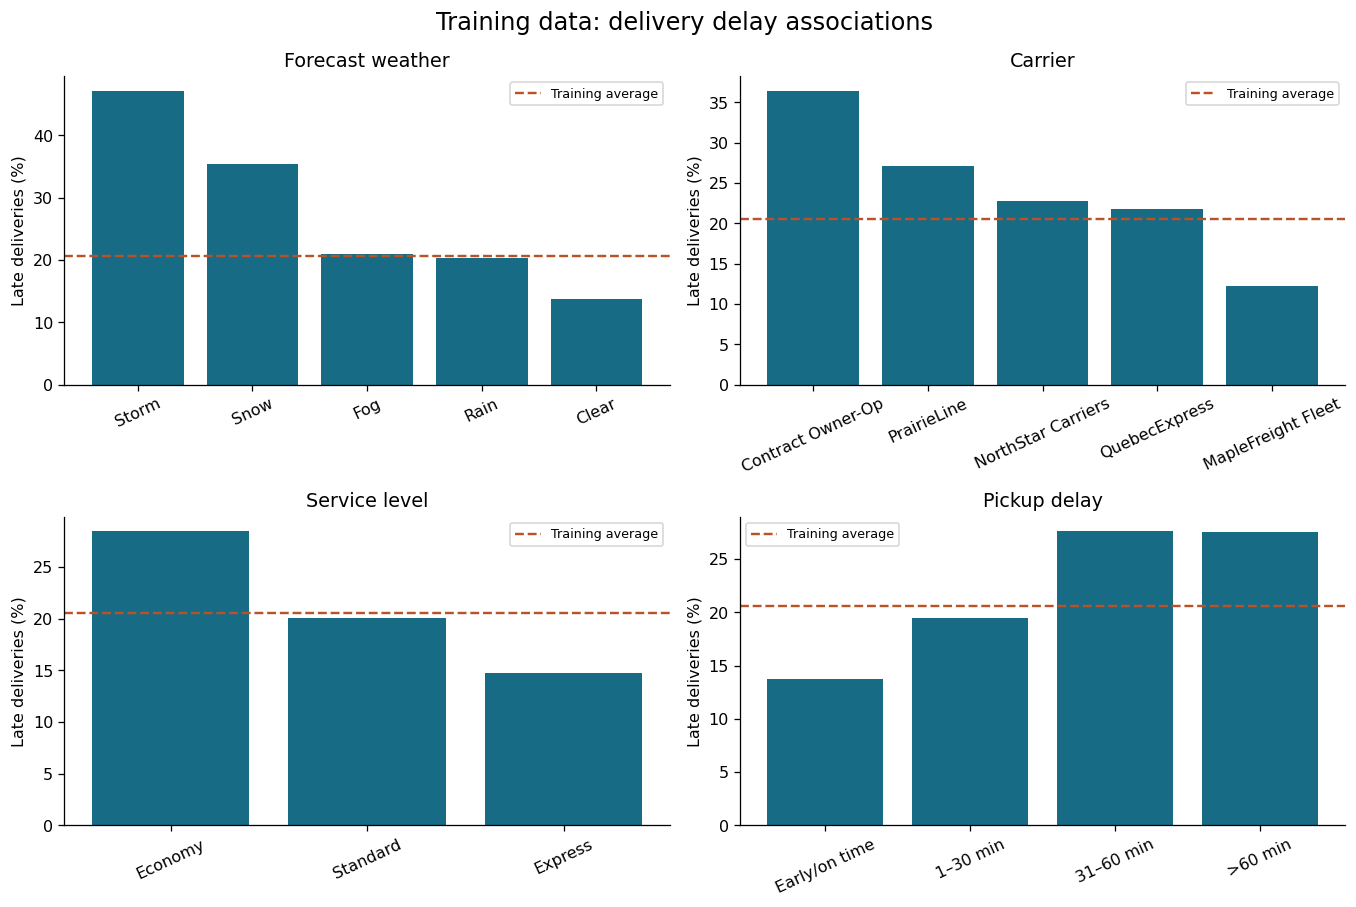

**Finding:** Storm has the highest observed weather late rate (47.2%). Late rates by pickup delay range from 13.7% to 27.6%. Carrier and service differences should be interpreted alongside route and weather mix.

In [5]:
eda = DispatchFeatures().transform(train[PREDICTORS])
eda[TARGET] = train[TARGET].to_numpy()
def grouped_rates(column):
    return eda.groupby(column, observed=True)[TARGET].agg(shipments='size', late_share='mean').sort_values('late_share', ascending=False)
weather_rates, carrier_rates, service_rates = [grouped_rates(c) for c in ['weather_condition', 'carrier', 'service_level']]
display(weather_rates)
display(carrier_rates)
display(service_rates)
eda['pickup_delay_band'] = pd.cut(eda.pickup_delay_minutes,
    bins=[-np.inf, 0, 30, 60, np.inf], labels=['Early/on time', '1–30 min', '31–60 min', '>60 min'])
pickup_rates = grouped_rates('pickup_delay_band').reindex(['Early/on time', '1–30 min', '31–60 min', '>60 min'])
display(pickup_rates)
numeric_associations = eda[NUMERIC + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(ascending=False)
display(numeric_associations.rename('correlation_with_lateness').to_frame())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, table, title in zip(axes.flat, [weather_rates, carrier_rates, service_rates, pickup_rates],
                          ['Forecast weather', 'Carrier', 'Service level', 'Pickup delay']):
    ax.bar(table.index.astype(str), table.late_share * 100, color='#176b85')
    ax.axhline(train[TARGET].mean() * 100, color='#b95226', linestyle='--', label='Training average')
    ax.set(title=title, ylabel='Late deliveries (%)')
    ax.tick_params(axis='x', labelrotation=25)
    ax.legend(fontsize=8)
fig.suptitle('Training data: delivery delay associations', fontsize=15)
fig.tight_layout()
fig.savefig(ROOT / 'reports/eda_late_rates.png', bbox_inches='tight')
plt.show()
worst_weather = weather_rates.index[0]
display(Markdown(f'**Finding:** {worst_weather} has the highest observed weather late rate '
    f'({weather_rates.iloc[0].late_share:.1%}). Late rates by pickup delay range from '
    f'{pickup_rates.late_share.min():.1%} to {pickup_rates.late_share.max():.1%}. '
    'Carrier and service differences should be interpreted alongside route and weather mix.'))

## 6. Preprocessing and feature engineering
The reusable transformer applies the same stateless rules in training and deployment.
Add cyclical month encodings, nonnegative pickup delay in hours, the fraction of the
scheduled transit budget already consumed by pickup delay, required average speed,
and a suspect-weight indicator. Required speed uses only the planned distance and
schedule. Fuel cost is the estimate available at dispatch, as described in the dictionary.

Median imputation with missingness indicators handles numeric gaps. Most-frequent
imputation handles missing categories, and one-hot encoding tolerates unseen categories.
Logistic regression also receives standardized numeric inputs.

In [6]:
display(Code(inspect.getsource(DispatchFeatures), language='python'))
def make_pipeline(estimator, scaled=False):
    numeric_steps = [('impute', SimpleImputer(strategy='median', add_indicator=True))]
    if scaled:
        numeric_steps.append(('scale', StandardScaler()))
    preprocessing = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), NUMERIC + ENGINEERED),
        ('category', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL)], remainder='drop')
    return Pipeline([('features', DispatchFeatures()),
                     ('preprocess', preprocessing), ('classifier', estimator)])
display(DispatchFeatures().transform(train[PREDICTORS])[ENGINEERED].head())
print('Raw dispatch predictors:', len(PREDICTORS), '| Engineered features:', len(ENGINEERED))
display(Markdown('**Finding:** Features use information available after pickup. '
    'The fitted pipeline owns all learned preprocessing, preventing validation/test statistics '
    'from leaking into training. Carrier history must be calculated strictly before each shipment.'))

class DispatchFeatures(BaseEstimator, TransformerMixin):
    """Stateless rules available after pickup; fitted imputation occurs downstream."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        missing = sorted(set(PREDICTORS) - set(X.columns))
        if missing:
            raise ValueError('Missing dispatch fields: ' + ', '.join(missing))
        frame = normalize_categories(X[PREDICTORS])
        for col in NUMERIC:
            frame[col] = pd.to_numeric(frame[col], errors='coerce').replace([np.inf, -np.inf], np.nan)
        frame['weight_suspect'] = (frame['weight_kg'] > 50000).astype(int)
        frame.loc[(frame['weight_kg'] > 50000) | (frame['weight_kg'] <= 0), 'weight_kg'] = np.nan
        for col in ['distance_km', 'scheduled_transit_hours']:
            frame.loc[frame[col] <= 0, col] = np.nan
        for col in ['num_stops', 'driver_experience_years', 'vehicle_age_years',
                    'prior_late_deliveries_30d', 'fuel_cost_cad']:
            frame.loc[frame[col] < 0, col] = np.nan
        for col, low, high in [('shipment_month', 1, 12), ('traffic_index', 0, 100),
                                ('route_congestion_score', 0, 1)]:
            frame.loc[~frame[col].between(low, high) & frame[col].notna(), col] = np.nan
        frame.loc[~frame['is_cross_border'].isin([0, 1]), 'is_cross_border'] = np.nan
        frame['month_sin'] = np.sin(2 * np.pi * frame['shipment_month'] / 12)
        frame['month_cos'] = np.cos(2 * np.pi * frame['shipment_month'] / 12)
        frame['pickup_delay_hours'] = frame['pickup_delay_minutes'].clip(lower=0) / 60
        frame['pickup_delay_budget_fraction'] = frame['pickup_delay_hours'] / frame['scheduled_transit_hours']
        frame['required_speed_kmh'] = frame['distance_km'] / frame['scheduled_transit_hours']
        return frame

,month_sin,month_cos,pickup_delay_hours,pickup_delay_budget_fraction,required_speed_kmh,weight_suspect
3359,-8.6603e-01,5.0000e-01,0.2333,0.0165,69.7663,0
1721,1.0000e+00,6.1232e-17,0.0000,0.0000,60.0372,0
4745,-2.4493e-16,1.0000e+00,0.0167,0.0021,41.4322,0
1136,-1.0000e+00,-1.8370e-16,0.0000,0.0000,58.2114,0
4329,8.6603e-01,5.0000e-01,0.4333,0.0468,50.8315,0


Raw dispatch predictors: 20 | Engineered features: 6


**Finding:** Features use information available after pickup. The fitted pipeline owns all learned preprocessing, preventing validation/test statistics from leaking into training. Carrier history must be calculated strictly before each shipment.

## 7. Baseline and model comparison
Start with an always-on-time dummy and an interpretable logistic regression.
Compare random forest and histogram gradient boosting against them. Real classifiers
use balanced class weights. Three-fold sigmoid calibration on training data brings
the weighted classifiers back toward probabilities at the observed class prevalence.

Choose the model with highest **validation average precision (AP)**, which evaluates
risk ranking across thresholds in this imbalanced problem. All candidates are reported
at 0.50 before tuning the selected model's alert threshold. These are fixed reasonable
configurations, not an exhaustive hyperparameter search.

In [7]:
def evaluate(y, probability, threshold=0.5):
    predicted = (probability >= threshold).astype(int)
    return {'threshold': float(threshold), 'accuracy': float(accuracy_score(y, predicted)),
        'precision': float(precision_score(y, predicted, zero_division=0)),
        'recall': float(recall_score(y, predicted, zero_division=0)),
        'f1': float(f1_score(y, predicted, zero_division=0)),
        'f2': float(fbeta_score(y, predicted, beta=2, zero_division=0)),
        'average_precision': float(average_precision_score(y, probability)),
        'roc_auc': float(roc_auc_score(y, probability)),
        'brier': float(brier_score_loss(y, probability)), 'alert_rate': float(predicted.mean()),
        'confusion_matrix': confusion_matrix(y, predicted, labels=[0, 1]).tolist()}
candidates = {
    'Logistic regression': make_pipeline(LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED), scaled=True),
    'Random forest': make_pipeline(RandomForestClassifier(class_weight='balanced', n_estimators=250,
        max_depth=12, min_samples_leaf=4, n_jobs=-1, random_state=SEED)),
    'Histogram gradient boosting': make_pipeline(HistGradientBoostingClassifier(class_weight='balanced',
        max_iter=180, max_leaf_nodes=15, min_samples_leaf=25, learning_rate=.08,
        l2_regularization=1, random_state=SEED))}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
models = {'Always on time': make_pipeline(DummyClassifier(strategy='most_frequent'))}
models.update({name: CalibratedClassifierCV(estimator=model, method='sigmoid', cv=cv, n_jobs=1)
               for name, model in candidates.items()})
validation_metrics, validation_probabilities = {}, {}
for name, model in models.items():
    start = time.perf_counter()
    model.fit(train[PREDICTORS], train[TARGET])
    probability = model.predict_proba(validation[PREDICTORS])[:, 1]
    validation_probabilities[name] = probability
    validation_metrics[name] = evaluate(validation[TARGET], probability)
    print(f'{name}: fitted in {time.perf_counter()-start:.1f} seconds')
metrics_columns = ['threshold', 'accuracy', 'precision', 'recall', 'f1',
                   'f2', 'average_precision', 'roc_auc', 'brier', 'alert_rate']
validation_table = pd.DataFrame(validation_metrics).T[metrics_columns].astype(float)
display(validation_table.sort_values('average_precision', ascending=False))
validation_table.to_csv(ROOT / 'reports/validation_model_comparison.csv')
chosen_name = max(candidates, key=lambda name: validation_metrics[name]['average_precision'])
chosen_model = models[chosen_name]
display(Markdown(f'**Finding:** **{chosen_name}** wins with validation AP '
    f'**{validation_metrics[chosen_name]["average_precision"]:.3f}**. '
    'The dummy detects no late shipments. Calibration aims to reduce probability bias from '
    'class weighting, but a 0.50 cutoff still misses many delays.'))

Always on time: fitted in 0.1 seconds


Logistic regression: fitted in 0.3 seconds


Random forest: fitted in 1.9 seconds


Histogram gradient boosting: fitted in 1.7 seconds


,threshold,accuracy,precision,recall,f1,f2,average_precision,roc_auc,brier,alert_rate
Logistic regression,0.5,0.8292,0.6909,0.3077,0.4258,0.3461,0.5607,0.8125,0.1258,0.0917
Histogram gradient boosting,0.5,0.8258,0.7639,0.2227,0.3448,0.2594,0.5437,0.8032,0.1297,0.0600
Random forest,0.5,0.8142,0.6250,0.2429,0.3499,0.2768,0.5201,0.7825,0.1331,0.0800
Always on time,0.5,0.7942,0.0000,0.0000,0.0000,0.0000,0.2058,0.5000,0.2058,0.0000


**Finding:** **Logistic regression** wins with validation AP **0.561**. The dummy detects no late shipments. Calibration aims to reduce probability bias from class weighting, but a 0.50 cutoff still misses many delays.

## 8. Choose and justify the alert threshold
Optimize validation F2, which emphasizes recall (beta squared = 4), subject to an
**assumed pilot alert-rate ceiling of 40%**. This capacity limit is an explicit planning
assumption, not observed dispatch staffing or a measured financial optimum.
Search thresholds 0.05–0.80 in 0.01 increments. Break F2 ties by higher precision and
then higher threshold. Lock the choice before evaluating the test set.

A 20% risk cutoff creates a broad dispatch review queue. A higher cutoff reduces
false alerts but misses more delayed shipments; the table makes that tradeoff visible.

,threshold,accuracy,precision,recall,f1,f2,average_precision,roc_auc,brier,alert_rate
5,0.1,0.5500,0.3049,0.9271,0.4589,0.6584,0.5607,0.8125,0.1258,0.6258
15,0.2,0.7233,0.4086,0.7692,0.5337,0.6538,0.5607,0.8125,0.1258,0.3875
25,0.3,0.7833,0.4778,0.5668,0.5185,0.5464,0.5607,0.8125,0.1258,0.2442
35,0.4,0.8075,0.5440,0.4008,0.4615,0.4231,0.5607,0.8125,0.1258,0.1517
45,0.5,0.8292,0.6909,0.3077,0.4258,0.3461,0.5607,0.8125,0.1258,0.0917


Chosen threshold: 0.2


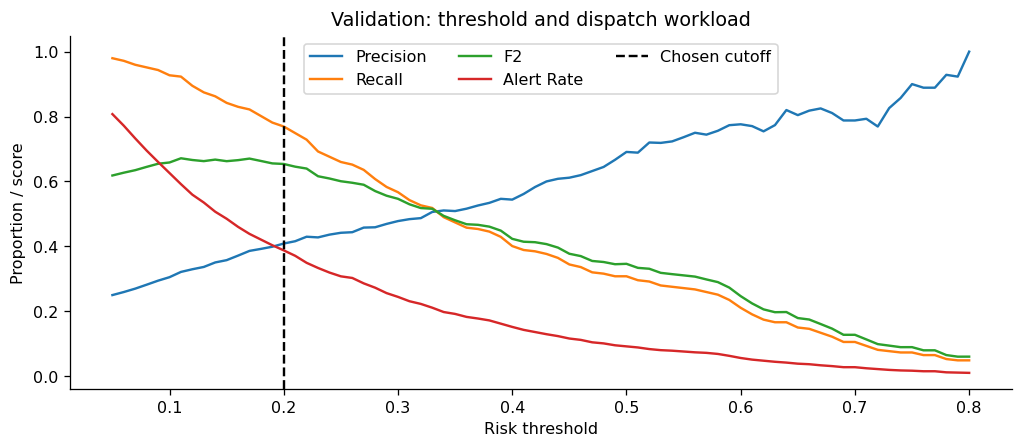

**Finding:** The chosen threshold is **0.20**. Validation recall is 76.9%, precision 40.9%, F2 0.654, and 38.8% of shipments enter the review queue. Dispatch should validate this workload before rollout.

In [8]:
threshold_table = pd.DataFrame([
    {k: v for k, v in evaluate(validation[TARGET], validation_probabilities[chosen_name], threshold).items()
     if k != 'confusion_matrix'}
    for threshold in np.round(np.arange(.05, .801, .01), 2)])
feasible = threshold_table.loc[threshold_table.alert_rate <= .40]
if feasible.empty:
    raise ValueError('No threshold satisfies the assumed capacity constraint.')
selected = feasible.sort_values(['f2', 'precision', 'threshold'], ascending=False).iloc[0]
ALERT_THRESHOLD = float(selected.threshold)
display(threshold_table.loc[threshold_table.threshold.isin([.10, .20, .30, .40, .50])])
print('Chosen threshold:', ALERT_THRESHOLD)
threshold_table.to_csv(ROOT / 'reports/validation_thresholds.csv', index=False)
fig, ax = plt.subplots(figsize=(9, 4))
for metric in ['precision', 'recall', 'f2', 'alert_rate']:
    ax.plot(threshold_table.threshold, threshold_table[metric], label=metric.replace('_', ' ').title())
ax.axvline(ALERT_THRESHOLD, linestyle='--', color='black', label='Chosen cutoff')
ax.set(xlabel='Risk threshold', ylabel='Proportion / score', title='Validation: threshold and dispatch workload')
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(ROOT / 'reports/threshold_tradeoff.png', bbox_inches='tight')
plt.show()
display(Markdown(f'**Finding:** The chosen threshold is **{ALERT_THRESHOLD:.2f}**. '
    f'Validation recall is {selected.recall:.1%}, precision {selected.precision:.1%}, '
    f'F2 {selected.f2:.3f}, and {selected.alert_rate:.1%} of shipments enter the review queue. '
    'Dispatch should validate this workload before rollout.'))

## 9. Final evaluation on untouched test data
Evaluate the majority baseline, the selected model at 0.50, and the locked alert
threshold. Test data is not used to choose the model or threshold. Confusion matrices
have actual classes on rows and predictions on columns: on time, then late.

,threshold,accuracy,precision,recall,f1,f2,average_precision,roc_auc,brier,alert_rate
Always on time (0.50),0.5,0.7942,0.0000,0.0000,0.0000,0.0000,0.2058,0.5000,0.2058,0.0000
Logistic regression (0.50),0.5,0.8300,0.6903,0.3158,0.4333,0.3542,0.5716,0.8172,0.1231,0.0942
Logistic regression (0.20),0.2,0.7275,0.4127,0.7652,0.5362,0.6535,0.5716,0.8172,0.1231,0.3817


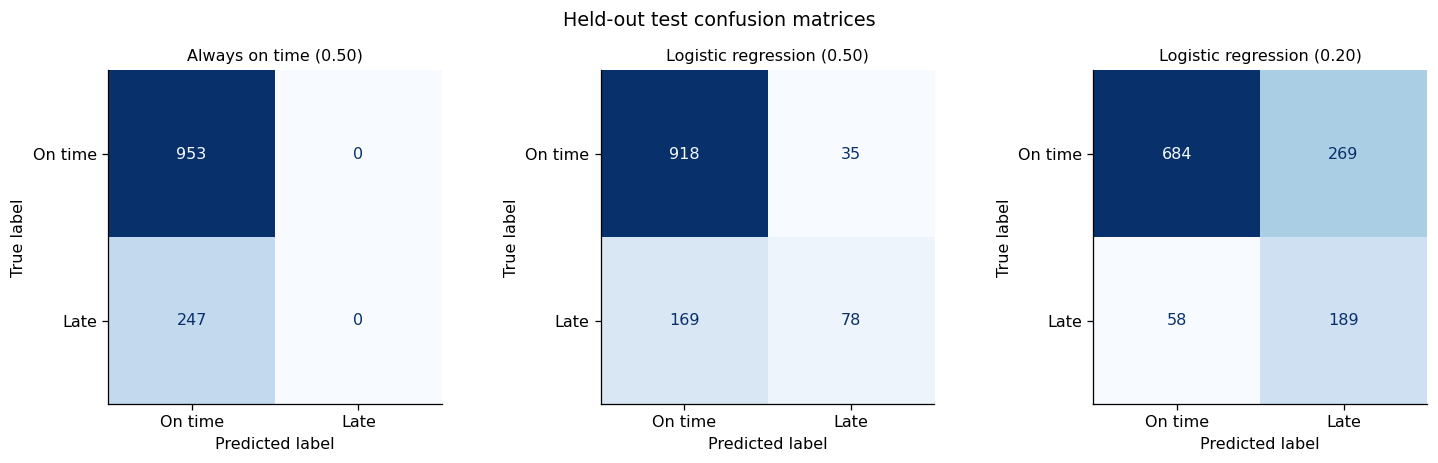

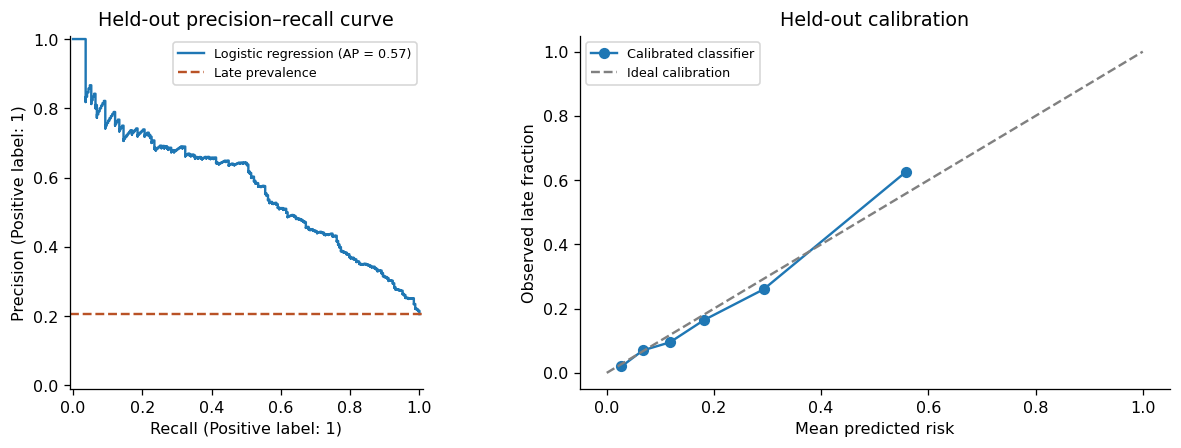

**Finding:** The model catches **189/247 late shipments (76.5%)**, with precision **41.3%**, F1 **0.536** and AP **0.572**. There are **458 alerts**, including **269 false alarms**, and **58 missed delays**. The lower accuracy than the majority baseline reflects the choice to detect delays.

In [9]:
test_probability = chosen_model.predict_proba(test[PREDICTORS])[:, 1]
baseline_probability = models['Always on time'].predict_proba(test[PREDICTORS])[:, 1]
test_metrics = {
    'Always on time (0.50)': evaluate(test[TARGET], baseline_probability),
    f'{chosen_name} (0.50)': evaluate(test[TARGET], test_probability),
    f'{chosen_name} ({ALERT_THRESHOLD:.2f})': evaluate(test[TARGET], test_probability, ALERT_THRESHOLD)}
display(pd.DataFrame(test_metrics).T[metrics_columns].astype(float))
pd.DataFrame(test_metrics).T[metrics_columns].to_csv(ROOT / 'reports/test_metrics.csv')
final_metrics = evaluate(test[TARGET], test_probability, ALERT_THRESHOLD)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, result) in zip(axes, test_metrics.items()):
    ConfusionMatrixDisplay(np.array(result['confusion_matrix']), display_labels=['On time', 'Late']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=10)
fig.suptitle('Held-out test confusion matrices')
fig.tight_layout()
fig.savefig(ROOT / 'reports/confusion_matrices.png', bbox_inches='tight')
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PrecisionRecallDisplay.from_predictions(test[TARGET], test_probability, ax=axes[0], name=chosen_name)
axes[0].axhline(test[TARGET].mean(), color='#b95226', linestyle='--', label='Late prevalence')
axes[0].set_title('Held-out precision–recall curve')
axes[0].legend(fontsize=8)
fraction_positive, mean_predicted = calibration_curve(test[TARGET], test_probability, n_bins=6, strategy='quantile')
axes[1].plot(mean_predicted, fraction_positive, marker='o', label='Calibrated classifier')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal calibration')
axes[1].set(xlabel='Mean predicted risk', ylabel='Observed late fraction', title='Held-out calibration')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(ROOT / 'reports/pr_and_calibration.png', bbox_inches='tight')
plt.show()
tn, fp, fn, tp = np.array(final_metrics['confusion_matrix']).ravel()
display(Markdown(f'**Finding:** The model catches **{tp}/{tp+fn} late shipments '
    f'({final_metrics["recall"]:.1%})**, with precision **{final_metrics["precision"]:.1%}**, '
    f'F1 **{final_metrics["f1"]:.3f}** and AP **{final_metrics["average_precision"]:.3f}**. '
    f'There are **{tp+fp} alerts**, including **{fp} false alarms**, and **{fn} missed delays**. '
    'The lower accuracy than the majority baseline reflects the choice to detect delays.'))

## 10. Model explainability
Permute one original feature at a time in validation data and measure the decrease
in AP. This explains which inputs the fitted risk ranking depends on, including
engineered features derived from the permuted input. Correlated inputs can share
importance. Importance is predictive evidence, not a causal intervention effect.

,feature,ap_decrease,std
6,weather_condition,0.1091,0.0123
8,distance_km,0.1047,0.0118
16,traffic_index,0.0804,0.0081
2,carrier,0.0785,0.0139
10,num_stops,0.0638,0.0114
13,pickup_delay_minutes,0.0400,0.0071
18,prior_late_deliveries_30d,0.0285,0.0090
3,service_level,0.0253,0.0111
17,route_congestion_score,0.0239,0.0027
14,driver_experience_years,0.0236,0.0053


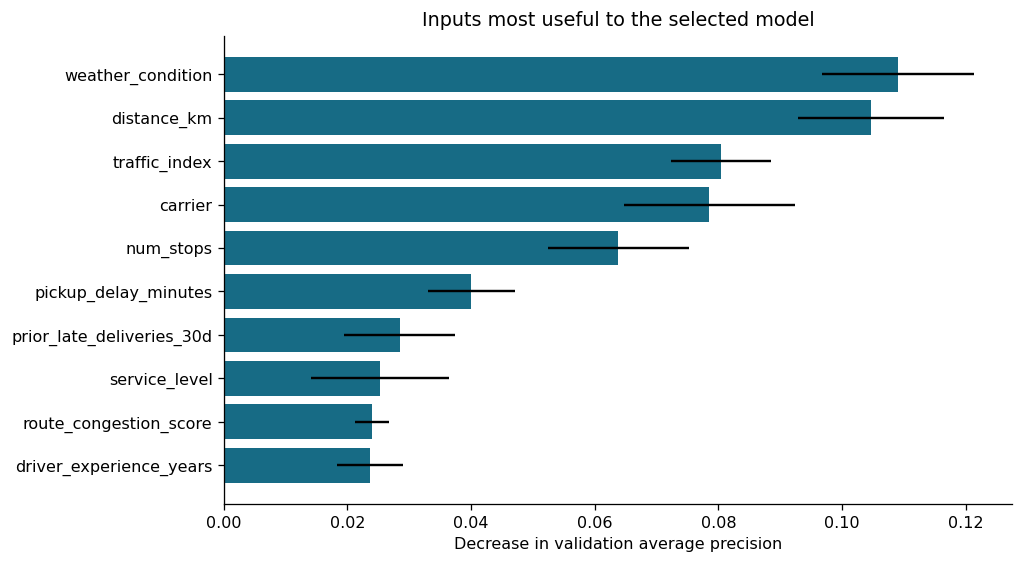

**Finding:** The three strongest inputs by validation permutation importance are **weather condition, distance km, traffic index**. Use these to prioritize review, while checking the shipment’s actual operational context.

In [10]:
permutation = permutation_importance(chosen_model, validation[PREDICTORS], validation[TARGET],
    scoring='average_precision', n_repeats=8, random_state=SEED, n_jobs=1)
importance = pd.DataFrame({'feature': PREDICTORS, 'ap_decrease': permutation.importances_mean,
                           'std': permutation.importances_std}).sort_values('ap_decrease', ascending=False)
display(importance.head(12))
importance.to_csv(ROOT / 'reports/permutation_importance.csv', index=False)
top = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.feature, top.ap_decrease, xerr=top['std'], color='#176b85')
ax.axvline(0, color='gray', linewidth=.7)
ax.set(xlabel='Decrease in validation average precision', title='Inputs most useful to the selected model')
fig.tight_layout()
fig.savefig(ROOT / 'reports/feature_importance.png', bbox_inches='tight')
plt.show()
display(Markdown('**Finding:** The three strongest inputs by validation permutation importance are **'
    + ', '.join(importance.head(3).feature.str.replace('_', ' '))
    + '**. Use these to prioritize review, while checking the shipment’s actual operational context.'))

## 11. Save the model and integrate Slack alerts
Persist the evaluated fitted pipeline and locked threshold together. Keep this model
trained on the training set; refitting after evaluation would change its probabilities
and require a fresh threshold/calibration check.

Score only dispatch fields from the held-out historical records, with target and
actual transit time removed. The phone-friendly alert gives the total at-risk count,
then ID, destination, carrier and risk for the top five. `.env` is ignored by Git,
and only `.env.example` belongs in the public repository.

**Real send:** Configure `SLACK_WEBHOOK_URL` privately and set `SLACK_ENABLED=true`
in `.env`. This cell then performs `requests.post(webhook, json={'text': message})`.
It validates Slack's acknowledgment, redacts credential-bearing errors and suppresses
repeated successful alerts using all at-risk shipments, not just the displayed five.
Capture the received message in Slack as `screenshots/slack_alert.png`.

In [11]:
bundle = {'model': chosen_model, 'threshold': ALERT_THRESHOLD, 'model_name': chosen_name,
          'feature_columns': PREDICTORS, 'prediction_time': 'after pickup',
          'source_sha256': source_hash, 'random_seed': SEED}
joblib.dump(bundle, ROOT / 'models/delivery_delay_model.joblib')
replay = test[['shipment_id'] + PREDICTORS].copy()
replay.to_csv(ROOT / 'data/replay_shipments.csv', index=False)
scored = score_shipments(bundle, replay)
scored.to_csv(ROOT / 'reports/historical_replay_scores.csv', index=False)
message, risky = build_alert(scored, ALERT_THRESHOLD, source='historical replay')
display(scored.head(5))
print(message or 'No high-risk shipments detected.')
(ROOT / 'reports/slack_alert_preview.txt').write_text(message or 'No high-risk shipments.', encoding='utf-8')
slack_status = post_alert(message, ROOT,
    event_key=alert_event_key(risky, ALERT_THRESHOLD, 'historical replay'))
print('Slack delivery status (credential redacted):')
display(pd.DataFrame([slack_status]))
screenshot_path = ROOT / 'screenshots/slack_alert.png'
display(Markdown('**Finding:** ' + (
    'Slack acknowledged the real message. Add the screenshot of the received alert.'
    if slack_status['status'] == 'sent' else
    'An identical message was already sent successfully.' if slack_status['status'] == 'already_sent' else
    'The alert is prepared, but a real Slack send is pending private webhook configuration. '
    'The text preview is not proof of delivery.')))

,shipment_id,destination_city,carrier,risk_score,high_risk
0,SHP-100936,Calgary AB,PrairieLine,0.9270,True
1,SHP-103230,Regina SK,Contract Owner-Op,0.8947,True
2,SHP-102910,Edmonton AB,QuebecExpress,0.8916,True
3,SHP-103300,Winnipeg MB,NorthStar Carriers,0.8874,True
4,SHP-105927,Calgary AB,QuebecExpress,0.8858,True


*MapleFreight: 458 of 1200 shipments at risk*
Historical replay | risk threshold 20%
Top 5 for dispatch review:
SHP-100936 — Calgary AB — PrairieLine — risk 92.7%
SHP-103230 — Regina SK — Contract Owner-Op — risk 89.5%
SHP-102910 — Edmonton AB — QuebecExpress — risk 89.2%
SHP-103300 — Winnipeg MB — NorthStar Carriers — risk 88.7%
SHP-105927 — Calgary AB — QuebecExpress — risk 88.6%
Action: review pickup delay, route traffic and forecast; assess rerouting or customer notice.
Assessment demonstration using historical data; these are not live shipments.


Slack delivery status (credential redacted):


,status,sent,http_status,slack_acknowledged,sent_at_utc,configured_channel_label,message_sha256,event_sha256
0,sent,True,200,True,2026-10-09T00:59:49.168782+00:00,#all-lambton-college-software,0588d163ea731417e6a3fdfa66b3331baad979352dcff9...,c788ad3c227a7487c6ac78d12213453347170518c88678...


**Finding:** Slack acknowledged the real message. Add the screenshot of the received alert.

## 12. Operational checks and recommendations
Check that post-delivery fields cannot change predictions, unseen categories remain
scoreable, normalized duplicate IDs are rejected, and alerts account for records
beyond the top five. These checks protect the model-to-alert workflow.

In [12]:
original = test[PREDICTORS].head(10).copy()
poisoned = original.assign(actual_transit_hours=999999, delivered_late=1, shipment_id='ignored')
assert np.allclose(chosen_model.predict_proba(original), chosen_model.predict_proba(poisoned))
unseen = original.copy()
unseen['carrier'] = 'Previously unseen carrier'
assert np.isfinite(chosen_model.predict_proba(unseen)).all()
duplicate = replay.head(1).copy()
alias = duplicate.copy()
alias['shipment_id'] = '  ' + alias.shipment_id.str.lower() + '  '
try:
    score_shipments(bundle, pd.concat([duplicate, alias]))
except ValueError:
    pass
else:
    raise AssertionError('Normalized duplicate IDs were not rejected.')
assert build_alert(scored.assign(risk_score=0), ALERT_THRESHOLD)[0] is None
altered = risky.copy()
if len(altered) > 5:
    altered.iloc[-1, altered.columns.get_loc('shipment_id')] = 'SHP-NEW-RECORD'
    assert alert_event_key(risky, ALERT_THRESHOLD, 'historical replay') != alert_event_key(altered, ALERT_THRESHOLD, 'historical replay')
print('PASS: leakage exclusion, unseen categories, normalized IDs, zero-risk batch and full-batch fingerprint.')
recommendations = pd.DataFrame([
    ['1', 'Review severe-weather / congested-route alerts', 'Check forecast and alternate routes before customer-window breach', 'Track delay recall and service credits in pilot'],
    ['2', 'Reduce pickup delays', 'Escalate delayed pickup and review dock scheduling', 'Track pickup delay bands and downstream late share'],
    ['3', 'Review carrier history with route context', 'Discuss repeated delays; match capacity to route requirements', 'Track carrier late rate adjusted for service and route mix'],
    ['4', 'Validate dispatch workload', 'Start with 0.20 cutoff; measure alert fatigue and intervention results', 'Track precision, queue size, response time and acknowledged alerts'],
    ['5', 'Improve source data and run a prospective pilot', 'Confirm weight units and label definition; add timestamps/status/ETA and historical cutoffs', 'Use future-dated holdout and compare intervention outcomes']
], columns=['Priority', 'Recommendation', 'Dispatch action', 'Measure'])
display(recommendations)
recommendations.to_csv(ROOT / 'reports/recommendations.csv', index=False)
weekly_alerts = 8000 * final_metrics['alert_rate']
display(Markdown(f'**Finding:** If the test alert rate transferred to 8,000 shipments/week, '
    f'the queue would contain approximately **{weekly_alerts:,.0f} alerts/week**. This is a '
    'planning projection, not observed demand. A prospective pilot should establish capacity, '
    'available lead time and whether interventions actually prevent delays.'))

PASS: leakage exclusion, unseen categories, normalized IDs, zero-risk batch and full-batch fingerprint.


,Priority,Recommendation,Dispatch action,Measure
0,1,Review severe-weather / congested-route alerts,Check forecast and alternate routes before cus...,Track delay recall and service credits in pilot
1,2,Reduce pickup delays,Escalate delayed pickup and review dock schedu...,Track pickup delay bands and downstream late s...
2,3,Review carrier history with route context,Discuss repeated delays; match capacity to rou...,Track carrier late rate adjusted for service a...
3,4,Validate dispatch workload,Start with 0.20 cutoff; measure alert fatigue ...,"Track precision, queue size, response time and..."
4,5,Improve source data and run a prospective pilot,Confirm weight units and label definition; add...,Use future-dated holdout and compare intervent...


**Finding:** If the test alert rate transferred to 8,000 shipments/week, the queue would contain approximately **3,053 alerts/week**. This is a planning projection, not observed demand. A prospective pilot should establish capacity, available lead time and whether interventions actually prevent delays.

## 13. Reproducibility, AI use and submission status
ChatGPT/Codex assisted with cleaning, model comparison, alert code and documentation.
One AI-generated implementation checked IDs before normalizing whitespace/case:
`SHP-1` and ` shp-1 ` could pass the duplicate check. Review exposed the error;
normalization now precedes ID validation, and the check above verifies the correction.

Source references: [scikit-learn decision-threshold guidance](https://scikit-learn.org/stable/modules/classification_threshold.html),
[Slack Incoming Webhooks](https://docs.slack.dev/messaging/sending-messages-using-incoming-webhooks/).

Limits: random historical evaluation, unresolved promised-window semantics,
uncertain source weight units, and no live tracking/status/deadline feed.
The genuine received-message screenshot is included below when available.
Repository: https://github.com/Ulviyya89/Software-Tools-and-Emerging--Assignment1

,Requirement,Status
0,Visible notebook outputs,Executed in this run
1,Baseline and final metrics,Reported
2,Locked threshold,"0.20, selected on validation"
3,Private credential template and ignore rule,Provided
4,Real Slack delivery,sent
5,Genuine Slack screenshot,Present
6,Public GitHub repository link,https://github.com/Ulviyya89/Software-Tools-an...


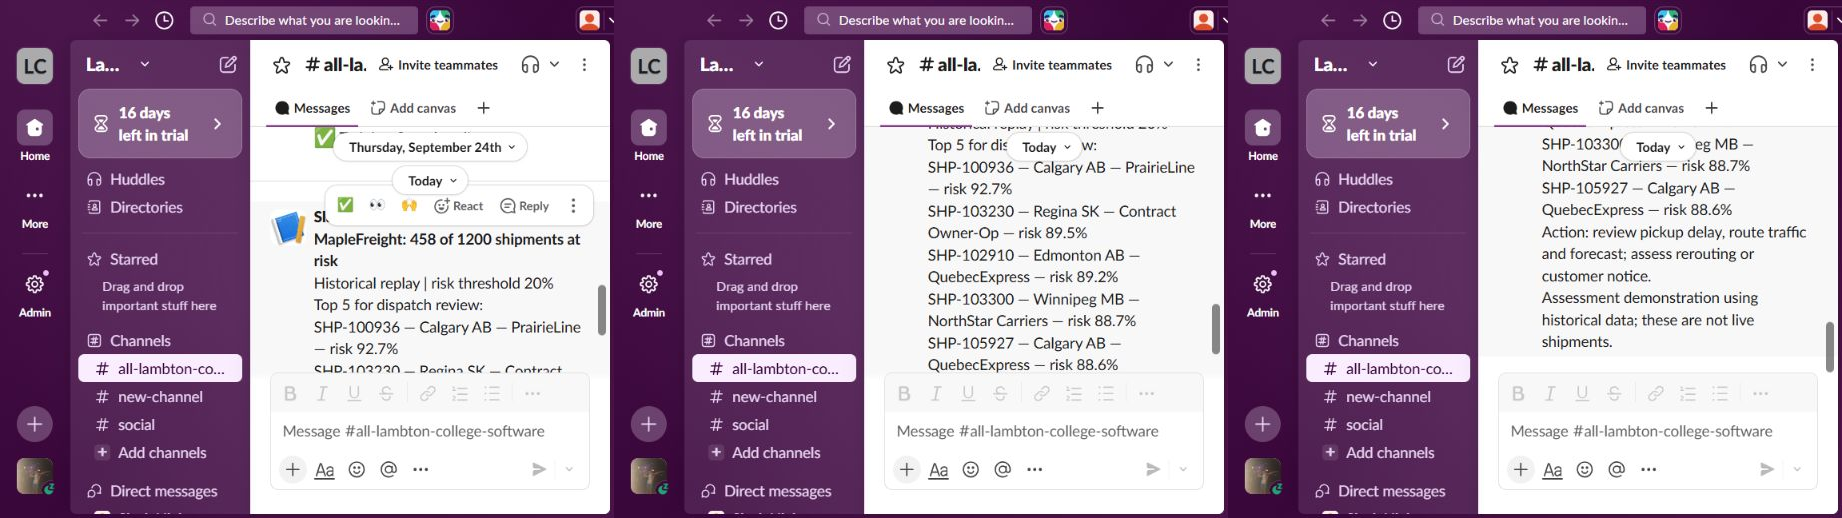

**Finding:** Model evaluation and alert generation are reproducible. The delivery status and genuine screenshot above document the Slack integration. Use the repository link for the course submission.

In [13]:
metrics_report = {'student_id': 'C0942109', 'source_sha256': source_hash,
    'data_audit': audit, 'model': chosen_name, 'threshold': ALERT_THRESHOLD,
    'threshold_rule': 'Maximum validation F2 with assumed alert rate <= 0.40',
    'validation_at_0_5': validation_metrics, 'final_test': test_metrics,
    'slack_status': slack_status, 'slack_screenshot_present': screenshot_path.exists(),
    'repository_url': 'https://github.com/Ulviyya89/Software-Tools-and-Emerging--Assignment1'}
(ROOT / 'reports/assessment_results.json').write_text(json.dumps(metrics_report, indent=2))
checklist = pd.DataFrame({
    'Requirement': ['Visible notebook outputs', 'Baseline and final metrics', 'Locked threshold',
                    'Private credential template and ignore rule', 'Real Slack delivery', 'Genuine Slack screenshot', 'Public GitHub repository link'],
    'Status': ['Executed in this run', 'Reported', f'{ALERT_THRESHOLD:.2f}, selected on validation',
               'Provided', slack_status['status'],
               'Present' if screenshot_path.exists() else 'Pending real screenshot',
               'https://github.com/Ulviyya89/Software-Tools-and-Emerging--Assignment1']})
display(checklist)
if screenshot_path.exists():
    display(Image(filename=str(screenshot_path)))
display(Markdown('**Finding:** Model evaluation and alert generation are reproducible. '
    'The delivery status and genuine screenshot above document the Slack integration. '
    'Use the repository link for the course submission.'))